### **Comparando Modelos**

In [1]:
# Importando Bibliotecas
import os
import pickle

from src.utils import set_seed
from src.evalutation.model_comparator import ModelComparator

set_seed(42)

### **Selecionando Modelos a serem comparados**

In [2]:
# Escolhendo modelos para comparar:
list_models = [r"data\model_weights\UNet_ImageNet\FocalMSEMaskedLoss_200ep",
               r"data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W",
               r"data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_48W"]

In [3]:
# Coletando Configurações dos modelos:
dict_config = {}
for model in list_models:
    with open(os.path.join(model,'config.pkl'), 'rb') as f:
        config_model = pickle.load(f)
        dict_config[model] = config_model

In [4]:
# Criando objeto de comparação
comp = ModelComparator(dict_config=dict_config)
dfMetrics = comp.calculate_metrics()

✓ Modelo carregado: data\model_weights\UNet_ImageNet\FocalMSEMaskedLoss_200ep\fold_1_best.pth
  Epoch: 2
  Val Loss: 0.0442

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:07<00:00, 23.11it/s]


HRNet 32 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\fold_1_best.pth
  Epoch: 17
  Val Loss: 0.0011

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:04<00:00, 35.79it/s]


HRNet 48 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_48W\fold_1_best.pth
  Epoch: 27
  Val Loss: 0.0011

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:05<00:00, 35.10it/s]


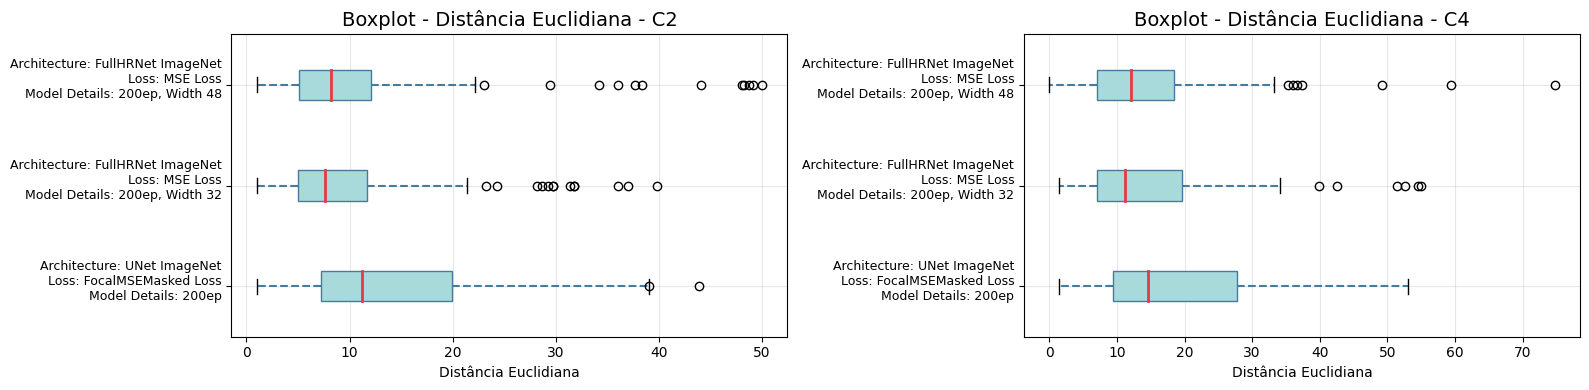

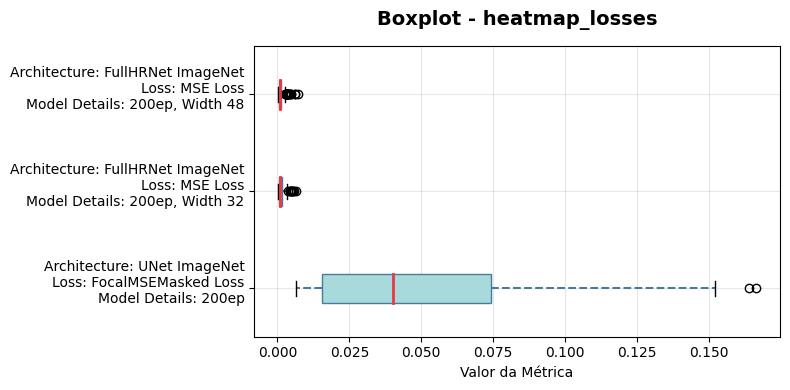

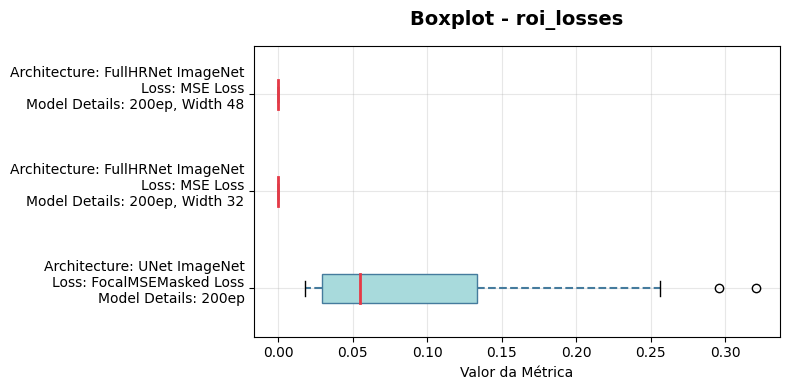

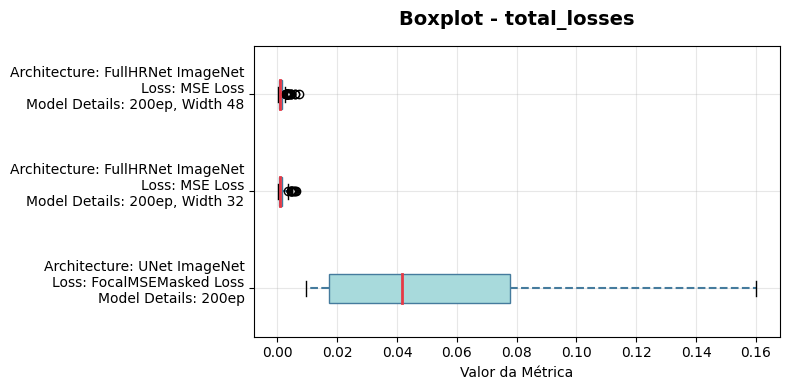

In [5]:
# Boxplot das Métricas
comp.plot_boxplot_metrics(["keypoint_distances", "heatmap_losses", "roi_losses", "total_losses"])

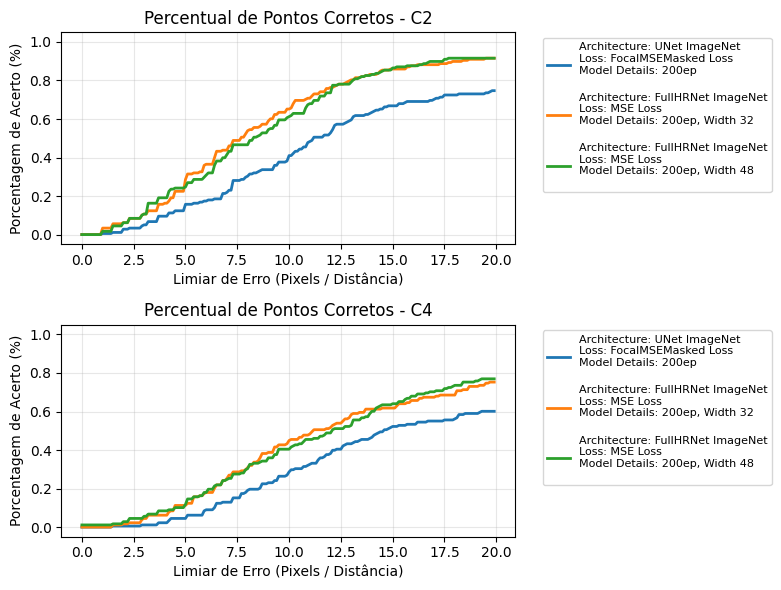

In [6]:
# Percentual de Pontos Corretos
comp.plot_percentage_correct_keypoint()